# Classifier Training — EfficientNet-V2-S (8 class)
**Classes:** `back_label`, `capsule_box`, `container_label`, `grade_bag`, `import_sticker`, `print_sticker_back`, `print_sticker_full`, `retail_sachet`

### โครงสร้าง Drive ที่ต้องการ
```
MyDrive/
└── pj-ocr-text-check-lot/
    ├── images/
    │   ├── back_label/
    │   ├── capsule_box/
    │   ├── container_label/
    │   ├── grade_bag/
    │   ├── import_sticker/
    │   ├── print_sticker_back/
    │   ├── print_sticker_full/
    │   └── retail_sachet/
    └── models/   ← model จะ save ที่นี่
```

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Config — แก้ path ตรงนี้ถ้าโฟลเดอร์ใน Drive ต่างออกไป

In [2]:
from pathlib import Path

# ── PATH ──────────────────────────────────────────────────────────────────────
DRIVE_ROOT  = Path('/content/drive/MyDrive/data classify check lot')
IMAGES_DIR  = DRIVE_ROOT / 'images'
MODEL_OUT   = DRIVE_ROOT / 'models' / 'classifier.pt'

# ── HYPERPARAMETERS ───────────────────────────────────────────────────────────
CLASSES      = sorted(['back_label', 'capsule_box', 'container_label', 'grade_bag',
                       'import_sticker', 'print_sticker_back', 'print_sticker_full', 'retail_sachet'])
IMG_SIZE     = 384      # V2-S pretrained ที่ 384 — ได้ผลดีกว่า 224 ชัดเจน
EPOCHS       = 50       # Stage1=25 epochs, Stage2=25 epochs
BATCH_SIZE   = 16       # T4 + IMG_SIZE 384
LR           = 3e-3     # head training
LR_FINETUNE  = 5e-5     # fine-tune ช้าลง ลด overfit
VAL_SPLIT    = 0.2
SEED         = 42
PATIENCE     = 10       # V2-S ต้องการ patience มากขึ้น
WEIGHT_DECAY = 1e-3     # เพิ่มจาก 1e-4

# สร้าง models/ ถ้ายังไม่มี
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
print('IMAGES_DIR:', IMAGES_DIR)
print('MODEL_OUT :', MODEL_OUT)

IMAGES_DIR: /content/drive/MyDrive/data classify check lot/images
MODEL_OUT : /content/drive/MyDrive/data classify check lot/models/classifier.pt


## 3. ติดตั้ง dependencies

In [3]:
!pip install -q tqdm scikit-learn matplotlib

## 4. Import & Device

In [4]:
import logging
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
from torchvision import models, transforms
from tqdm.notebook import tqdm

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s — %(message)s')
logger = logging.getLogger(__name__)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 5. ตรวจสอบ Dataset

In [5]:
total = 0
for cls in CLASSES:
    d = IMAGES_DIR / cls
    imgs = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.webp']:
        imgs += list(d.glob(ext))
    total += len(imgs)
    print(f'{cls:20s}: {len(imgs)} images')
print(f'{"TOTAL":20s}: {total} images')

back_label          : 161 images
capsule_box         : 45 images
container_label     : 200 images
grade_bag           : 166 images
import_sticker      : 301 images
print_sticker_back  : 200 images
print_sticker_full  : 200 images
retail_sachet       : 149 images
TOTAL               : 1422 images


## 6. Dataset & Transforms

In [6]:
TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.TrivialAugmentWide(),               # policy-based augmentation — effective สำหรับ small dataset
    # 4-way rotation — รับมือรูปพลิก 90/180/270 องศา (แต่ละทิศมีโอกาส 25%)
    transforms.RandomChoice([
        transforms.Lambda(lambda x: x),           # 0° (ปกติ)
        transforms.RandomRotation((90, 90)),       # 90°
        transforms.RandomRotation((180, 180)),     # 180°
        transforms.RandomRotation((270, 270)),     # 270°
    ]),
    transforms.RandomRotation(15),                 # jitter เล็กน้อยบนทุก orientation
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomAffine(degrees=20, shear=15, scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.RandomSolarize(threshold=128, p=0.2),       # จำลองรูปที่ถ่ายแสงจ้า
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),  # จำลองรูปเบลอ/ชัด
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

VAL_TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class LotImageDataset(Dataset):
    """โหลดรูปจาก images/<class>/ และ assign label ตาม class index"""

    def __init__(self, images_dir: Path, classes: list, transform=None):
        self.transform = transform
        self.samples = []
        for idx, cls in enumerate(classes):
            cls_dir = images_dir / cls
            if not cls_dir.exists():
                logger.warning('Directory not found: %s', cls_dir)
                continue
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.webp'):
                for img_path in cls_dir.glob(ext):
                    self.samples.append((img_path, idx))
        logger.info('Dataset: %d images across %d classes', len(self.samples), len(classes))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

## 7. Model

In [7]:
def build_model(num_classes: int) -> nn.Module:
    """EfficientNet-V2-S pretrained, replace classifier head with Dropout"""
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

def freeze_backbone(model: nn.Module) -> None:
    for name, param in model.named_parameters():
        param.requires_grad = 'classifier' in name

def unfreeze_all(model: nn.Module) -> None:
    for param in model.parameters():
        param.requires_grad = True

## 8. Training Loop

In [8]:
def run_epoch(model, loader, criterion, optimizer, phase):
    is_train = phase == 'train'
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in tqdm(loader, desc=phase, leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train and optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total

## 9. Train!

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
torch.manual_seed(SEED)

# Dataset
full_dataset = LotImageDataset(IMAGES_DIR, CLASSES, transform=TRAIN_TRANSFORMS)
all_indices  = list(range(len(full_dataset)))
all_labels   = [full_dataset.samples[i][1] for i in all_indices]

# Stratified split — ทุก class ได้สัดส่วน 80/20 เท่ากัน
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=VAL_SPLIT,
    stratify=all_labels,
    random_state=SEED,
)

train_ds = torch.utils.data.Subset(full_dataset, train_indices)

val_full = LotImageDataset(IMAGES_DIR, CLASSES, transform=VAL_TRANSFORMS)
val_ds   = torch.utils.data.Subset(val_full, val_indices)

# แสดงจำนวนรูปต่อ class หลัง split
train_labels = [full_dataset.samples[i][1] for i in train_indices]
val_labels   = [full_dataset.samples[i][1] for i in val_indices]
print('Class split (train / val):')
for idx, cls in enumerate(CLASSES):
    t = train_labels.count(idx)
    v = val_labels.count(idx)
    print(f'  {cls:25s}: {t:3d} train / {v:2d} val')

# WeightedRandomSampler
class_counts = torch.zeros(len(CLASSES))
for lbl in train_labels:
    class_counts[lbl] += 1
class_weights  = 1.0 / class_counts.clamp(min=1)
sample_weights = torch.tensor([class_weights[lbl] for lbl in train_labels])
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,  num_workers=2, pin_memory=True)

class_weights_loss = class_weights.to(DEVICE)
model = build_model(num_classes=len(CLASSES)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_loss, label_smoothing=0.1)

best_val_acc = 0.0
patience_counter = 0
STAGE1_EPOCHS = EPOCHS // 2
STAGE2_EPOCHS = EPOCHS - STAGE1_EPOCHS

# ── Stage 1: train head only ──────────────────────────────────────────────────
print(f'\n=== Stage 1: head only ({STAGE1_EPOCHS} epochs) ===')
freeze_backbone(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

for epoch in range(STAGE1_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, 'train')
    val_loss, val_acc     = run_epoch(model, val_loader,   criterion, None,      'val')
    print(f'Epoch {epoch+1:2d}/{STAGE1_EPOCHS} | train loss={train_loss:.4f} acc={train_acc:.3f} | val loss={val_loss:.4f} acc={val_acc:.3f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({'model_state': model.state_dict(), 'classes': CLASSES}, MODEL_OUT)
        print(f'  -> Saved best model (val_acc={best_val_acc:.3f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  -> Early stopping at epoch {epoch+1}')
            break

# ── Stage 2: fine-tune all layers (AdamW + OneCycleLR) ───────────────────────
print(f'\n=== Stage 2: fine-tune all ({STAGE2_EPOCHS} epochs) ===')
unfreeze_all(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR_FINETUNE * 10,
    steps_per_epoch=len(train_loader),
    epochs=STAGE2_EPOCHS,
    pct_start=0.3,
)
patience_counter = 0

for epoch in range(STAGE2_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, 'train')
    val_loss, val_acc     = run_epoch(model, val_loader,   criterion, None,      'val')
    scheduler.step()
    print(f'Epoch {epoch+1:2d}/{STAGE2_EPOCHS} | train loss={train_loss:.4f} acc={train_acc:.3f} | val loss={val_loss:.4f} acc={val_acc:.3f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({'model_state': model.state_dict(), 'classes': CLASSES}, MODEL_OUT)
        print(f'  -> Saved best model (val_acc={best_val_acc:.3f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  -> Early stopping at epoch {epoch+1}')
            break

print(f'\nDone! Best val accuracy: {best_val_acc:.3f}')
print(f'Model saved to: {MODEL_OUT}')

Class split (train / val):
  back_label               : 129 train / 32 val
  capsule_box              :  36 train /  9 val
  container_label          : 160 train / 40 val
  grade_bag                : 133 train / 33 val
  import_sticker           : 240 train / 61 val
  print_sticker_back       : 160 train / 40 val
  print_sticker_full       : 160 train / 40 val
  retail_sachet            : 119 train / 30 val
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 75.4MB/s]



=== Stage 1: head only (25 epochs) ===


train:   0%|          | 0/72 [00:00<?, ?it/s]

val:   0%|          | 0/18 [00:00<?, ?it/s]

...

val:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 24/25 | train loss=0.5004 acc=0.987 | val loss=0.6006 acc=1.000


train:   0%|          | 0/72 [00:00<?, ?it/s]

val:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 25/25 | train loss=0.4947 acc=0.995 | val loss=0.6007 acc=1.000

Done! Best val accuracy: 1.000
Model saved to: /content/drive/MyDrive/data classify check lot/models/classifier.pt


## 10. Confusion Matrix (optional)

                    precision    recall  f1-score   support

        back_label       1.00      1.00      1.00        32
       capsule_box       1.00      1.00      1.00         9
   container_label       1.00      1.00      1.00        40
         grade_bag       1.00      1.00      1.00        33
    import_sticker       1.00      1.00      1.00        61
print_sticker_back       1.00      1.00      1.00        40
print_sticker_full       1.00      1.00      1.00        40
     retail_sachet       1.00      1.00      1.00        30

          accuracy                           1.00       285
         macro avg       1.00      1.00      1.00       285
      weighted avg       1.00      1.00      1.00       285



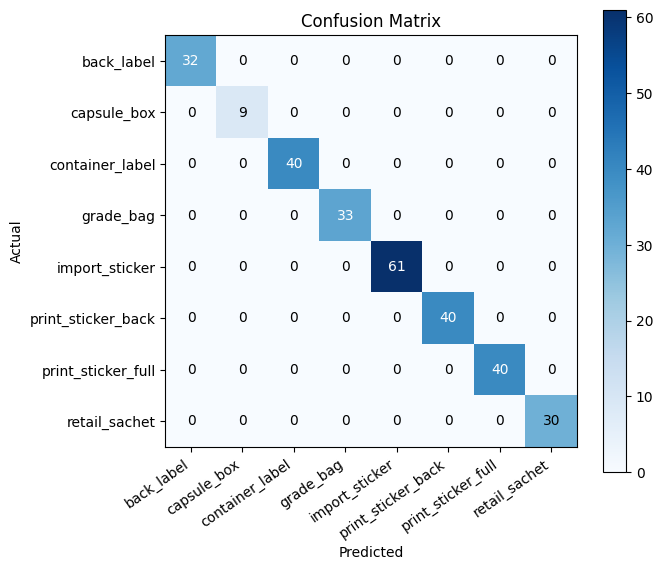

Saved confusion_matrix.png to Drive


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# โหลด best model
ckpt = torch.load(MODEL_OUT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=35, ha='right')
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(DRIVE_ROOT / 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved confusion_matrix.png to Drive')